In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer

Učitati skup podataka iz priloga vježbe ’SpamDetectionData.csv’ te prikazati prva 3 podatka kako bi se upoznali
sa formatom skupa podataka. Koje su kolone u ovom skupu podataka?

In [35]:
spam = pd.read_csv('SpamDetectionData.txt')
print(spam[:3])


  Label                                            Message
0  Spam  <p>But could then once pomp to nor that glee g...
1  Spam  <p>His honeyed and land vile are so and native...
2  Spam  <p>Tear womans his was by had tis her eremites...


Iz skupa podataka izdvojiti X i y pri čemu je X skup poruka, a y pridružene labele. Zatim ukloniti iz poruka
html tagove \<p> i \</p> s obzirom da se oni nalaze u svakoj poruci. Koliko slova ima prva, a koliko druga
rečenica iz skupa podataka?

In [36]:
import re #regex
X = spam['Message']
y = spam['Label']

X = X.apply(lambda s: re.sub(r"</?p>", "", s) if isinstance(s, str) else s)
print(X.head())
print(y.head())

print(f"Prva recenica ima {len(X[0])}")
print(f"Druga recenica ima {len(X[1])}")

0    But could then once pomp to nor that glee glor...
1    His honeyed and land vile are so and native fr...
2    Tear womans his was by had tis her eremites th...
3    The that and land. Cell shun blazon passion un...
4    Sing aught through partings things was sacred ...
Name: Message, dtype: object
0    Spam
1    Spam
2    Spam
3    Spam
4    Spam
Name: Label, dtype: object
Prva recenica ima 417
Druga recenica ima 859


Podijeliti skup podataka na dio za treniranje i testiranje pri čemu 10% ukupnog skupa se treba uzeti kao testni set;

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(f"Trening skup: {X_train.shape}, Test skup: {X_test.shape}")

Trening skup: (1890,), Test skup: (210,)


Izvršiti tokenizaciju teksta korištenjem Tokenizer objekta kao što je opisano u vježbi. Vokabular generisati
na osnovu trening podataka. Nakon toga, na osnovu generisanog rječnika pretvoriti sve poruke (i iz trening i
test skupa) iz teksta u niz cijelih brojeva. Koje su tri najčešće riječi u tekstu? Kako izgleda prva rečenica iz
trening skupa podataka, a kako izgleda formirani niz cijelih brojeva za nju?


In [38]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
train_data_seq = tokenizer.texts_to_sequences(X_train)
test_data_seq = tokenizer.texts_to_sequences(X_test)

#print(tokenizer.word_index) # Ispisuje generisani rjecnik
#print(tokenizer.word_counts) # Ispisuje broj ponavljanja svake od rijeci u tekstu

word_count = tokenizer.word_counts
sorted_words = sorted(word_count.items(), key = lambda x: x[1], reverse=True)

print(f"Tri najčešće riječi u tekstu: {sorted_words[:3]}")
print(f"Prva rečenica iz trening skupa: {X_train.iloc[0]}")
print(f"Formirani niz cijelih brojeva za prvu rečenicu: {train_data_seq[0]}")


Tri najčešće riječi u tekstu: [('the', 23042), ('and', 19393), ('of', 11189)]
Prva rečenica iz trening skupa: Fluttered dreary a the of yore stock and curious we many wore the the radiant bust tapping sir this. The ghost distinctly and quoth angels the chamber broken or ghost sitting grave its this. The dreaming and art when adore and moment then and lord she lent i quoth adore tell mystery mefilled. Still nevermore the fiery above rare hath ever my and.Lining each no peering mefilled token and one ghastly the. The seraphim the on the flutter there in to sad desolate gently many then my little. Name napping above said pondered from while.Stood unseen came plume my horror there nevermore caught flitting again a still get or and thy muttered. Had to divining hath whether implore and human balm all it by guessing here have curtain such here. Explore my implore beating sitting. But nevermore tempter before sent my sought our for have. Till on grave censer this with into merely air entreati

Kao što smo se mogli uvjeriti u zadatku b), nemaju sve rečenice istu dužinu. To se može riješiti vektorizacijom.
Definisati funkcije vectorize_sequences(sequences, dimension) i vectorize_labels(labels).
Prva funkcija treba da vrši vektorizaciju ulaznih podataka i prima kao prvi parametar nizove cijelih brojeva
koji su rezultat prethodnog podzadatka. Kao drugi parametar treba da prima broj na koju dužinu treba
vektorizovati te nizove. Druga funkcija, vectorize_labels, treba da vrši vektorizaciju labela pri čemu labeli
’spam’ dodijeliti vrijednost 1, a klasi ’ham’ vrijednost 0. Pozvati ove funkcije nad vrijednostima dobijenim pod
c) pri čemu vektorizaciju ulaznih podataka vršiti na vektore od 4000 elemenata;


In [39]:
def vectorize_sequences(sequences, dimension=4000):
  rez = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    rez[i, sequence] = 1
  return rez

def vectorize_labels(labels):
  return np.array([1 if label == 'spam' else 0 for label in labels])


# Vektorizacija sekvenci
X_train_vectorized = vectorize_sequences(train_data_seq) # dimension = 4000
X_test_vectorized = vectorize_sequences(test_data_seq)   # dimension = 4000

# Vektorizacija labela
y_train_vectorized = vectorize_labels(y_train)
y_test_vectorized = vectorize_labels(y_test)

print(f"X_train_vectorized shape: {X_train_vectorized.shape}")
print(f"X_test_vectorized shape: {X_test_vectorized.shape}")
print(f"y_train_vectorized shape: {y_train_vectorized.shape}")
print(f"y_test_vectorized shape: {y_test_vectorized.shape}")

X_train_vectorized shape: (1890, 4000)
X_test_vectorized shape: (210, 4000)
y_train_vectorized shape: (1890,)
y_test_vectorized shape: (210,)


Definisati sekvencijalni Keras model koji prima ulaz oblika (4000,). Prva dva skrivena sloja trebaju biti
Dense i imati 8 neurona sa aktivacijskom funkcijom relu. Izlazni sloj treba imati jedan neuron i imati
sigmoid aktivacijsku funkciju;

In [40]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(8, activation = 'relu', input_shape=(4000,)))
model.add(layers.Dense(8, activation = 'relu'))
model.add(layers.Dense(1, activation = 'sigmoid'))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 8)                   │          32,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,089 (125.35 KB)

 Trainable params: 32,089 (125.35 KB)

 Non-trainable params: 0 (0.00 B)

Kompajlirati model tako da koristi rmsprop optimizator, za funkciju gubitka koristiti binary_crossentropy,
te accuracy kao metriku;

In [41]:
model.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

Istrenirati model na 5 epoha sa veličinom batcha od 128. 30% skupa za treniranje koristiti za validaciju. Kolika
je postignuta tačnost i vrijednost funkcije gubitka? Grafički prikazati;

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7743 - loss: 0.4015 - val_accuracy: 1.0000 - val_loss: 0.0606
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0524 - val_accuracy: 1.0000 - val_loss: 0.0233
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0233 - val_accuracy: 1.0000 - val_loss: 0.0111
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 0.0029
Postignuta tačnost na testnom skupu: 1.0000
Vrijednost funkcije gubitka: 0.0031


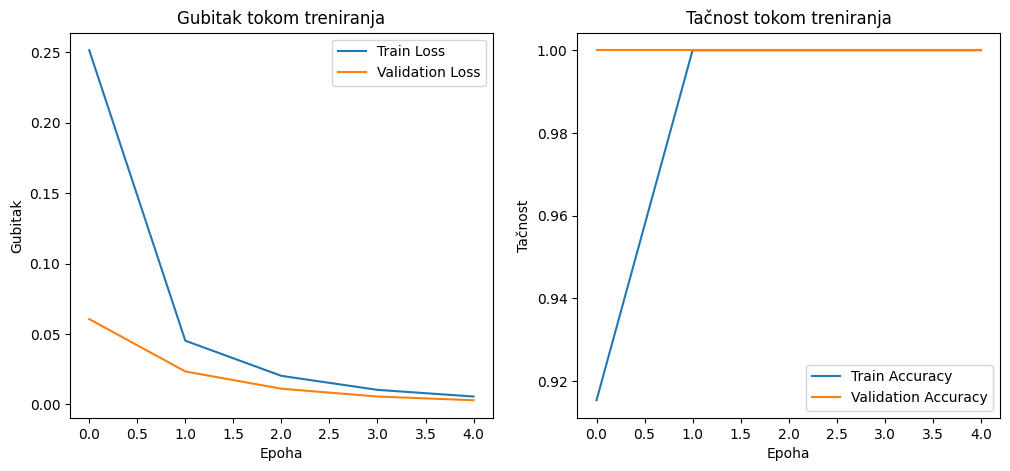

In [42]:
history = model.fit(X_train_vectorized, y_train_vectorized,
                    epochs=5,
                    batch_size=128,
                    validation_split=0.3,
                    verbose=1)

loss, accuracy = model.evaluate(X_test_vectorized, y_test_vectorized, verbose = 0)
print(f"Postignuta tačnost na testnom skupu: {accuracy:.4f}")
print(f"Vrijednost funkcije gubitka: {loss:.4f}")

plt.figure(figsize = (12,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoha")
plt.ylabel("Gubitak")
plt.legend()
plt.title("Gubitak tokom treniranja")

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoha")
plt.ylabel("Tačnost")
plt.legend()
plt.title("Tačnost tokom treniranja")

plt.show()

Izvršiti evaluaciju modela nad testnim skupom podataka. Kolika je tačnost nad ovim skupom?


In [44]:
print(f"Postignuta tačnost na testnom skupu: {accuracy:.4f}")
print(f"Vrijednost funkcije gubitka: {loss:.4f}")

Postignuta tačnost na testnom skupu: 1.0000
Vrijednost funkcije gubitka: 0.0031


#Definišite proizvoljnu poruku, pomoću tokenizera formirajte niz cijelih brojeva, vektorizujte ga i provjerite da li model ispravno klasificira tu poruku.

In [51]:
poruka = ["Congratulations! You won a free ticket to USA! Claim now at: www.fakelink.com"]

# Prvo provjerite kako izgleda tokenizirana poruka
sekvence = tokenizer.texts_to_sequences(poruka)
print("Tokenizirana poruka (indeksi riječi):", sekvence)

# Vektorizacija
vektorisana_poruka = vectorize_sequences(sekvence)
print("Broj jedinica u vektoriziranoj poruci:", np.sum(vektorisana_poruka))  # Trebalo bi biti >0

# Predikcija
rez = model.predict(vektorisana_poruka)
print("Raw prediction output:", rez)

# Klasifikacija
if rez[0][0] > 0.5:
    print(f"SPAM (vjerovatnoća: {rez[0][0]:.4f})")
else:
    print(f"HAM (vjerovatnoća: {1 - rez[0][0]:.4f})")

Tokenizirana poruka (indeksi riječi): [[168, 4, 6, 75, 20, 102, 103]]
Broj jedinica u vektoriziranoj poruci: 7.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Raw prediction output: [[0.3872535]]
HAM (vjerovatnoća: 0.6127)


Zadatak 2 - Višeklasna klasifikacija - klasificiranje Stackoverflow pitanja
U ovom zadatku ćemo se upoznati sa višeklasnom klasifikacijom. Problem koji će se rješavati je klasifikacija pitanja
sa Stack Overflow platforme (https://stackoverflow.com/). Skup podataka se sastoji od pitanja iz nekoliko
programskih jezika. I ovdje se radi o NLP te će se koristiti tokenizacija. Cilj klasifikacije jeste na osnovu pitanja sa
Stack Overflow odrediti na koji se programski jezik pitanje odnosi. Primjer tipičnog Stack Overflow pitanja je dat
na slici ??


a) Učitati ’stackoverflow.csv’ skup podataka iz priloga vježbe i prikazati posljednja tri podatka;

In [59]:
data = pd.read_csv('stackoverflow.csv')
print(spam[-3:])

                                                   post  tags
1987  directory folder name to put user defined pack...  java
1988  send message to server java  i m creating chat...  java
1989  how to add pattern of  *  is url-pattern in we...  java


b) Izdvojiti iz skupa podataka X i y, odnosno skup pitanja i skup odgovarajučih labela respektivno. Koliko ima
jedinstvenih labela, odnosno iz koliko programskih jezika se nalaze pitanja u skupu podataka? Koji su to
programski jezici?

In [60]:
X = data['post']
y = data['tags']

unique_labels = y.unique()
print(f"Broj jedinstvenih labela (programskih jezika): {len(unique_labels)}")
print("Programski jezici:")
print(unique_labels)

Broj jedinstvenih labela (programskih jezika): 4
Programski jezici:
['java' 'javascript' 'c#' 'python']


c) Izvršiti one-hot enkodiranje labela - prvo tekstualne labele mapirati u cijeli broj pomoću LabelEncoder objekta iz sklearn.preprocessing modula. Izvršiti one-hot enkodiranje labela korištenjem to_categorical
funkcije iz keras.utils modula. Ispisati dobijeni niz labela;

In [61]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# One-hot enkodiranje
y_one_hot = to_categorical(y_encoded)

print("Originalne labele (prvih 5):")
print(y[:5].values)

print("\nNumerički kodirane labele (prvih 5):")
print(y_encoded[:5])

print("\nOne-hot enkodirane labele (prvih 5):")
print(y_one_hot[:5])

print("\nMapiranje labela:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Originalne labele (prvih 5):
['java' 'javascript' 'c#' 'python' 'java']

Numerički kodirane labele (prvih 5):
[1 2 0 3 1]

One-hot enkodirane labele (prvih 5):
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]

Mapiranje labela:
c# -> 0
java -> 1
javascript -> 2
python -> 3


d) Podijeliti skup podataka na dio za treniranje i testiranje pri čemu 10% ukupnog skupa se treba uzeti kao testni
set;

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_one_hot,
    test_size=0.1,
    random_state=42,
    stratify=y_encoded
)

print(f"Broj primjera za trening: {len(X_train)}")
print(f"Broj primjera za testiranje: {len(X_test)}")

Broj primjera za trening: 1791
Broj primjera za testiranje: 199


e) Tokenizirati i vektorizovati tekst (pitanja) slično kao u prethodnom zadatku. Prilikom tokenizacije uzimati
u obzir samo 500 najčešćih riječi (ovo se može definisati pri samom formiranju Tokenizer objekta pomoću
jednog od parametara). Prema ovome prilagoditi i parametar dimensions pri vektorizaciji;

In [73]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer.num_words = 500

train_data_seq = tokenizer.texts_to_sequences(X_train)
test_data_seq = tokenizer.texts_to_sequences(X_test)

maxlen = 100
X_train_pad = pad_sequences(train_data_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(test_data_seq, maxlen=maxlen, padding='post', truncating='post')

print("\n--- Nakon ograničavanja na 500 riječi i paddinga ---")
print(f"Oblik trening podataka: {X_train_pad.shape}")
print(f"Oblik test podataka: {X_test_pad.shape}")
print(f"\nPrimjer prve rečenice nakon paddinga:\n{X_train_pad[0]}")


--- Nakon ograničavanja na 500 riječi i paddinga ---
Oblik trening podataka: (1791, 100)
Oblik test podataka: (199, 100)

Primjer prve rečenice nakon paddinga:
[  2   5   4   1   1  19   4  13  13 214   2  89  21   1 229 363  63 144
 363 363 145  24   5  11   5  46 145 145   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]


f) Definisati sekvencijalni Keras model sa 3 Dense sloja. Prvi treba imati 32 neurona, drugi 8 neurona, a
posljednji, koji je i izlazni treba imati onoliko neurona koliko ima klasa u ovom problemu. Aktivacijske funkcije
prva dva sloja postaviti na relu, a posljednjeg sloja na softmax;

In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

num_classes = y_train.shape[1]

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_pad.shape[1],)),
    Dense(8, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


g) Kompajlirati model tako da se koristi adam optimizator, categorical_crossentropy funkcija gubitka i
accuracy metrika. Prikazati sažetak (eng. summary) modela;

In [75]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 32)                  │           3,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,532 (13.80 KB)

 Trainable params: 3,532 (13.80 KB)

 Non-trainable params: 0 (0.00 B)

h) Istrenirati model na 8 epoha sa veličinom batcha 8. Izdvojiti 25% trening skupa da se koristi za validaciju.
Kolika je postignuta tačnost modela I kolika je vrijednost funkcije gubitka? Grafički prikazati;

Epoch 1/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2119 - loss: 21.9942 - val_accuracy: 0.2098 - val_loss: 1.9606
Epoch 2/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2611 - loss: 1.5711 - val_accuracy: 0.2143 - val_loss: 1.7019
Epoch 3/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2543 - loss: 1.4380 - val_accuracy: 0.2210 - val_loss: 1.6314
Epoch 4/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2623 - loss: 1.3798 - val_accuracy: 0.2165 - val_loss: 1.6001
Epoch 5/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2702 - loss: 1.3785 - val_accuracy: 0.2165 - val_loss: 1.6038
Epoch 6/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2754 - loss: 1.3756 - val_accuracy: 0.2188 - val_loss: 1.6159
Epoch 7/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2629 - loss: 1.3683 - val_accuracy: 0.2188 - val_loss: 1.6153
Epoch 8/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2793 - loss: 1.3620 - val_accuracy: 0.2188 - 

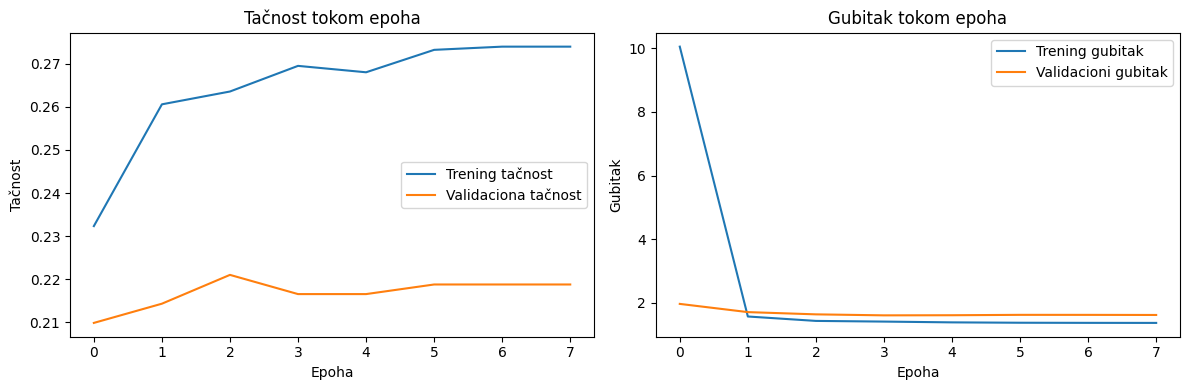

In [76]:
from tensorflow.keras.callbacks import History
import matplotlib.pyplot as plt

history = model.fit(
    X_train_pad,
    y_train,
    epochs=8,
    batch_size=8,
    validation_split=0.25,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nFinalna tačnost na testnom skupu: {test_acc:.4f}")
print(f"Finalni gubitak na testnom skupu: {test_loss:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Trening tačnost')
plt.plot(history.history['val_accuracy'], label='Validaciona tačnost')
plt.title('Tačnost tokom epoha')
plt.xlabel('Epoha')
plt.ylabel('Tačnost')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Trening gubitak')
plt.plot(history.history['val_loss'], label='Validacioni gubitak')
plt.title('Gubitak tokom epoha')
plt.xlabel('Epoha')
plt.ylabel('Gubitak')
plt.legend()

plt.tight_layout()
plt.show()

i) Izvršiti evaluaciju modela nad testnim skupom. Kolika je tačnost nad ovim skupom?


In [77]:
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)

print(f"Tačnost modela na testnom skupu: {test_accuracy:.4f}")
print(f"Vrijednost funkcije gubitka na testnom skupu: {test_loss:.4f}")

Tačnost modela na testnom skupu: 0.2412
Vrijednost funkcije gubitka na testnom skupu: 1.5534


# 1. Definisanje poboljšanog modela


In [84]:
from tensorflow.keras.layers import Embedding, LSTM, Dropout

model = Sequential([
    Embedding(input_dim=500, output_dim=64, input_length=maxlen),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# 2. Kompilacija modela
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 2. Treniranje sa EarlyStopping


In [85]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.25,
    callbacks=[EarlyStopping(patience=3)]  # Zaustavlja treniranje ako se gubitak ne smanjuje
)


Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.2590 - loss: 1.3865 - val_accuracy: 0.2344 - val_loss: 1.3861
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.2972 - loss: 1.3836 - val_accuracy: 0.2411 - val_loss: 1.3825
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - accuracy: 0.3108 - loss: 1.3791 - val_accuracy: 0.2679 - val_loss: 1.3518
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.3382 - loss: 1.3681 - val_accuracy: 0.2969 - val_loss: 1.3325
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.3295 - loss: 1.3352 - val_accuracy: 0.2879 - val_loss: 1.3246
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.3105 - loss: 1.3385 - val_accuracy: 0.2500 - val_loss: 1.3523
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.3071 - loss: 1.3429 - val_accuracy: 0.3013 - val_loss: 1.3147
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.3512 - loss: 1.3831 - val_accuracy

# 3. Evaluacija


In [86]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nTačnost na testnom skupu: {test_acc:.4f}")
print(f"Gubitak na testnom skupu: {test_loss:.4f}")


Tačnost na testnom skupu: 0.2864
Gubitak na testnom skupu: 1.3571


# 4. Vizualizacija


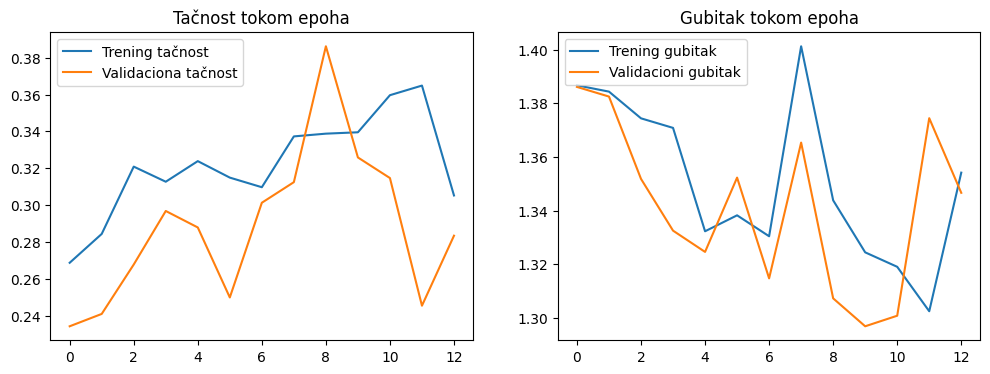

In [88]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Trening tačnost')
plt.plot(history.history['val_accuracy'], label='Validaciona tačnost')
plt.title('Tačnost tokom epoha')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Trening gubitak')
plt.plot(history.history['val_loss'], label='Validacioni gubitak')
plt.title('Gubitak tokom epoha')
plt.legend()
plt.show()